In [10]:
import pandas as pd
from pathlib import Path

In [ ]:
import torch
import torch_geometric
print(torch_geometric.__file__)

In [13]:
# Root directory where all project folders are stored
BASE_DIR = Path("ready/")
columns_to_keep = [
    'task_id', 'proj_id', 'rsrc_type'
]

def load_all_task_files(base_dir, keep_columns=None):
    base_dir = BASE_DIR
    all_dfs = []

    for project_dir in base_dir.iterdir():
        if project_dir.is_dir():
            task_path = project_dir / "TASKRSRC.csv"
            if task_path.exists():
                try:
                    df = pd.read_csv(
                        task_path,
                        usecols=keep_columns,
                        encoding='utf-8',
                        low_memory=False
                    )

                    all_dfs.append(df)

                except Exception as e:
                    print(f"[ERROR] Failed to load {task_path}: {e}")
                    continue

    if all_dfs:
        return pd.concat(all_dfs, ignore_index=True)
    else:
        print("[INFO] No task files loaded.")
        return pd.DataFrame()



In [14]:
df_all_res = load_all_task_files(
    base_dir=BASE_DIR,
    keep_columns=columns_to_keep,
)

df_res_pivoted = (
    df_all_res.assign(present=1)
      .pivot_table(index=['task_id', 'proj_id'], 
                   columns='rsrc_type', 
                   values='present', 
                   fill_value=0)
      .reset_index()
)

df_res_pivoted

rsrc_type,task_id,proj_id,RT_Equip,RT_Labor,RT_Mat
0,36777,374,0.0,0.0,1.0
1,36778,374,0.0,0.0,1.0
2,36781,374,0.0,0.0,1.0
3,36782,374,0.0,0.0,1.0
4,36783,374,0.0,0.0,1.0
...,...,...,...,...,...
87328,12457188,14517,0.0,1.0,0.0
87329,12457230,14517,0.0,1.0,0.0
87330,12457251,14517,0.0,1.0,0.0
87331,12457253,14517,0.0,1.0,0.0


In [ ]:
# Root directory where all project folders are stored
BASE_DIR = Path("projects/")

def load_task_file(project_dir):
    task_path = project_dir / "TASK.csv"
    if task_path.exists():
        try:
            df = pd.read_csv(
                task_path,
                parse_dates=[
                    'target_start_date', 'target_end_date',
                    'act_start_date', 'act_end_date'
                ],
                dayfirst=False,
                encoding='utf-8',
                low_memory=False  # fixes the warning
                # Remove invalid kwarg: errors='ignore'
            )
            return df
        except Exception as e:
            print(f"[ERROR] Failed to read {task_path}: {e}")
            return None
    return None

def add_schedule_features(df):
    # Ensure dates are parsed properly
    df['delay_days'] = (df['act_end_date'] - df['target_end_date']).dt.days
    df['duration_diff'] = (df['act_end_date'] - df['act_start_date']).dt.days - df['target_drtn_hr_cnt'] / 8
    df['on_time_flag'] = df['delay_days'].apply(lambda x: 1 if pd.notnull(x) and x <= 0 else 0)
    
    # You can also add:
    df['float_ratio'] = df.apply(lambda row: row['total_float_hr_cnt'] / row['target_drtn_hr_cnt']
                                 if row['target_drtn_hr_cnt'] != 0 else 0, axis=1)
    return df

all_dfs = []

for project_dir in BASE_DIR.iterdir():
    if project_dir.is_dir():
        df_task = load_task_file(project_dir)
        if df_task is not None:
            df_task = add_schedule_features(df_task)
            df_task['project_id'] = project_dir.name  # add project identifier
            all_dfs.append(df_task)

df_all_projects = pd.concat(all_dfs, ignore_index=True)

# Example stats
print(df_all_projects[['delay_days', 'on_time_flag', 'float_ratio']].describe())


         delay_days   on_time_flag    float_ratio
count  10409.000000  130111.000000  123456.000000
mean       1.632145       0.046560      13.921507
std       52.913236       0.210696      30.412706
min     -810.000000       0.000000     -67.165414
25%       -8.000000       0.000000       1.583333
50%        0.000000       0.000000       5.500000
75%       11.000000       0.000000      13.833333
max      509.000000       1.000000     631.016667


In [16]:
df_all_projects1a = df_all_projects.join(
    df_res_pivoted.set_index(['task_id', 'proj_id']),
    on=['task_id', 'proj_id'],
    how='left',
)

In [17]:
# Convert to datetime just to be safe
df_all_projects['act_end_date'] = pd.to_datetime(df_all_projects['act_end_date'], errors='coerce')

# Group by project and check if all act_end_date values are NaT
invalid_projects = (
    df_all_projects.groupby('proj_id')['act_end_date']
    .apply(lambda col: col.isna().all())
)

# Get only the projects with at least one valid act_end_date
valid_project_ids = invalid_projects[~invalid_projects].index

# Filter the main DataFrame
df_all_projects2 = df_all_projects[df_all_projects['proj_id'].isin(valid_project_ids)]
df_all_projects2

,Unnamed: 0,task_id,proj_id,wbs_id,clndr_id,est_wt,phys_complete_pct,rev_fdbk_flag,lock_plan_flag,auto_compute_act_flag,...,update_user,delay_days,duration_diff,on_time_flag,float_ratio,project_id,old_restart_date,old_reend_date,old_remain_drtn_hr_cnt,location_id
0,0,84949,859,10572,842,0.0,0.0,N,N,N,...,admin,NaN,NaN,0,0.0,129 trial,NaN,NaN,NaN,NaN
1,1,84950,859,10572,720,0.0,100.0,N,N,N,...,admin,0.0,0.000,1,0.0,129 trial,NaN,NaN,NaN,NaN
2,2,84951,859,10572,720,1.0,100.0,N,N,N,...,admin,-1.0,-69.000,1,NaN,129 trial,NaN,NaN,NaN,NaN
3,3,84952,859,10572,720,1.0,100.0,N,N,N,...,admin,0.0,16.125,1,NaN,129 trial,NaN,NaN,NaN,NaN
4,4,84953,859,10573,842,0.0,0.0,N,N,N,...,admin,NaN,NaN,0,0.0,129 trial,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130106,64,90652,794,11907,841,0.0,0.0,N,N,N,...,admin,NaN,NaN,0,0.0,Update 01-09-2010,NaN,NaN,NaN,NaN
130107,65,90653,794,11915,841,1.0,0.0,N,N,N,...,admin,NaN,NaN,0,0.0,Update 01-09-2010,NaN,NaN,NaN,NaN
130108,66,90654,794,11915,841,1.0,0.0,N,N,N,...,admin,NaN,NaN,0,0.0,Update 01-09-2010,NaN,NaN,NaN,NaN
130109,67,90655,794,11915,841,1.0,0.0,N,N,N,...,admin,NaN,NaN,0,0.0,Update 01-09-2010,NaN,NaN,NaN,NaN


In [18]:
#proof that the filter worked >> should remove projects with no work actuals
df_all_projects2a = df_all_projects[~df_all_projects['proj_id'].isin(valid_project_ids)]
df_all_projects2a['act_start_date'].count()

1

In [ ]:
df_all_projects2['est_end_date'] = df_all_projects2['target_start_date'] + pd.to_timedelta(
    df_all_projects2['target_drtn_hr_cnt'], unit='h'
)

df_all_projects2['delta_vs_est'] = (
    df_all_projects2['act_end_date'] - df_all_projects2['est_end_date']
).dt.days

df_all_projects2 = df_all_projects2.copy()

In [ ]:
df_all2 = df_all_projects2[['proj_id', 'task_id', 'phys_complete_pct','rev_fdbk_flag','lock_plan_flag',
'task_type','task_name','status_code','delay_days', 'on_time_flag', 'float_ratio','driving_path_flag',
 'act_work_qty',
 'remain_work_qty',
 'target_work_qty',
 'target_drtn_hr_cnt',
 'target_equip_qty',
 'act_equip_qty',
 'remain_equip_qty',
 'suspend_date',
 'resume_date',
 'act_start_date',
 'act_end_date',
 'act_end_date',
 'target_start_date',
 'target_end_date',
 'est_end_date',
 'delta_vs_est',]]

df_all2['has_suspend'] = df_all2['suspend_date'].notna().astype(int)
df_all2['has_resume'] = df_all2['resume_date'].notna().astype(int)

df_all2 = df_all2.copy()  # Create a copy to avoid SettingWithCopyWarning
df_all2.columns

In [21]:
len(df_all_projects1a['proj_id'].unique())

51

In [22]:
# ---- Config ----
categorical_cols = ['rev_fdbk_flag', 'lock_plan_flag', 'task_type', 'status_code', 'driving_path_flag']
numeric_cols = [
    'phys_complete_pct', 'float_ratio', 'act_work_qty', 'remain_work_qty', 'target_work_qty',
    'target_drtn_hr_cnt', 'target_equip_qty', 'act_equip_qty', 'remain_equip_qty'
]
date_cols = ['target_start_date', 'target_end_date']
target_col = 'on_time_flag'


# ---- Feature Engineering ----
def prepare_features(df, encoders=None, fit_encoders=False):
    df = df.copy()

    # Dates → ordinal
    for col in date_cols:
        df[col + '_ordinal'] = pd.to_datetime(df[col], errors='coerce').map(
            lambda x: x.toordinal() if pd.notnull(x) else -1
        )

    X = df[numeric_cols + [col + '_ordinal' for col in date_cols] + categorical_cols].copy()

    # Encode categoricals
    encoders_out = encoders or {}
    for col in categorical_cols:
        if fit_encoders:
            le = SafeLabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            encoders_out[col] = le
        else:
            X[col] = encoders_out[col].transform(X[col].astype(str))

    return X, encoders_out

In [37]:
# Step 1: Filter only completed tasks with valid labels
df_train = df_all2[
    (df_all2['status_code'] == 'TK_Complete') &
    (df_all2['on_time_flag'].notna())
].copy()

# Step 2: Add ordinal-encoded dates
date_features = ['target_start_date', 'target_end_date']
for col in date_features:
    df_train[col + '_ordinal'] = pd.to_datetime(df_train[col], errors='coerce').map(
        lambda x: x.toordinal() if pd.notnull(x) else -1
    )

# Step 3: Binary encode Y/N flags
binary_map = {'Y': 1, 'N': 0}
for col in ['rev_fdbk_flag', 'lock_plan_flag', 'driving_path_flag']:
    df_train[col] = df_train[col].map(binary_map).fillna(0)

# Step 4: One-hot encode categorical columns
categorical_cols = ['status_code', 'task_type']
df_train = pd.get_dummies(df_train, columns=categorical_cols, drop_first=True)

# Step 5: Define final feature list AFTER all transformations
final_feature_cols = [
    'phys_complete_pct', 'float_ratio', 'act_work_qty', 'remain_work_qty',
    'target_work_qty', 'target_drtn_hr_cnt', 'target_equip_qty',
    'act_equip_qty', 'remain_equip_qty', 'has_suspend', 'has_resume',
    'target_start_date_ordinal', 'target_end_date_ordinal',
    'rev_fdbk_flag', 'lock_plan_flag', 'driving_path_flag',
] + [col for col in df_train.columns if col.startswith('status_code_') or col.startswith('task_type_')]

# Step 6: Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_train[final_feature_cols] = scaler.fit_transform(df_train[final_feature_cols])



In [38]:
df_all2[['status_code',  'task_type']].head()

,status_code,task_type
37055,TK_Complete,TT_Task
37038,TK_Complete,TT_Task
36782,TK_Complete,TT_Task
37236,TK_Complete,TT_Mile
36777,TK_Complete,TT_Task


In [24]:
df_train.columns

Index(['proj_id', 'task_id', 'phys_complete_pct', 'rev_fdbk_flag',
       'lock_plan_flag', 'task_name', 'delay_days', 'on_time_flag',
       'float_ratio', 'driving_path_flag', 'act_work_qty', 'remain_work_qty',
       'target_work_qty', 'target_drtn_hr_cnt', 'target_equip_qty',
       'act_equip_qty', 'remain_equip_qty', 'suspend_date', 'resume_date',
       'act_start_date', 'act_end_date', 'act_end_date', 'target_start_date',
       'target_end_date', 'est_end_date', 'delta_vs_est', 'has_suspend',
       'has_resume', 'target_start_date_ordinal', 'target_end_date_ordinal',
       'task_type_TT_LOE', 'task_type_TT_Mile', 'task_type_TT_Task',
       'task_type_TT_WBS'],
      dtype='object')

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

def train_classifier(df_train, final_feature_cols, target_col="on_time_flag"):
    # Extract features and target
    X = df_train[final_feature_cols]
    y = df_train[target_col]

    # Split into train/validation sets
    X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Train a Random Forest model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_split, y_train_split)

    # Evaluate
    y_pred = model.predict(X_val_split)
    print(classification_report(y_val_split, y_pred))

    return model, X_val_split, y_val_split

model, X_val_split, y_val_split = train_classifier(df_train, final_feature_cols)

              precision    recall  f1-score   support

           0       0.76      0.79      0.77       870
           1       0.84      0.82      0.83      1212

    accuracy                           0.81      2082
   macro avg       0.80      0.80      0.80      2082
weighted avg       0.81      0.81      0.81      2082



In [ ]:
# ---- Risk Prediction ----
def predict_risk(df_all2, model, final_feature_cols):
    df_predict = df_all2[
        df_all2['status_code'].isin(['TK_NotStart', 'TK_Active'])
    ].copy()

    # Map binary Y/N to 1/0
    binary_map = {'Y': 1, 'N': 0}
    for col in ['rev_fdbk_flag', 'lock_plan_flag', 'driving_path_flag']:
        df_predict[col] = df_predict[col].map(binary_map).fillna(0)

    # Ordinalize dates
    for col in ['target_start_date', 'target_end_date']:
        df_predict[col + '_ordinal'] = pd.to_datetime(df_predict[col], errors='coerce').map(
            lambda x: x.toordinal() if pd.notnull(x) else -1
        )

    # One-hot encode
    df_predict = pd.get_dummies(df_predict, columns=['status_code', 'task_type'], drop_first=True)

    # Ensure all expected columns exist (add missing dummies with zeros)
    for col in final_feature_cols:
        if col not in df_predict.columns:
            df_predict[col] = 0

    # Ensure correct column order
    X_predict = df_predict[final_feature_cols]

    # Scale
    X_predict_scaled = scaler.transform(X_predict)

    # Predict risk
    df_predict['risk_score'] = model.predict_proba(X_predict_scaled)[:, 0]
    df_predict['alert'] = df_predict['risk_score'] > 0.5

    return df_predict[['proj_id', 'task_id', 'risk_score', 'alert']]


In [ ]:
# Step 1: Start clean
df_all_clean = df_all2.copy()

# Step 2: Fix date types (optional if already parsed)
df_all_clean['target_start_date'] = pd.to_datetime(df_all_clean['target_start_date'], errors='coerce')

# Step 3: Sort per project and assign local task sequence ID
df_all_clean = df_all_clean.sort_values(by=['proj_id', 'target_start_date']).reset_index(drop=True)
df_all_clean['local_task_seq_id'] = df_all_clean.groupby('proj_id').cumcount() + 1

# Step 4: Generate risk scores directly on the clean df
df_risk_output = predict_risk(df_all_clean, model, final_feature_cols)

# Step 5: Merge *back* only what you need
df_all_with_risk = df_all_clean.merge(
    df_risk_output[['proj_id', 'task_id', 'risk_score', 'alert']],
    on=['proj_id', 'task_id'],
    how='left'  # preserve all rows
)

# Step 6: Final columns
df_all6 = df_all_with_risk[['proj_id', 'task_id', 'local_task_seq_id', 'on_time_flag','risk_score', 'alert']].copy()
df_all6['risk_score'] = df_all6['risk_score'].fillna(0)
df_all6['alert'] = df_all6['alert'].fillna(False)

In [ ]:
# Sort first by project and sequence
df_all6_sorted = df_all6.sort_values(by=['proj_id', 'local_task_seq_id'])

# Identify first sequence index where on_time_flag drops from 1 to 0
def find_first_miss(group):
    group = group.sort_values('local_task_seq_id')
    prev_flag = group['on_time_flag'].shift(1, fill_value=1)  # assume starts with on-time
    transition = (prev_flag == 1) & (group['on_time_flag'] == 0)
    result = group.loc[transition, 'local_task_seq_id']
    return result.iloc[0] if not result.empty else None

# Apply to each project
first_miss_dict = df_all6_sorted.groupby('proj_id').apply(find_first_miss).reset_index()
first_miss_dict.columns = ['proj_id', 'first_seq_miss']

# Merge back to main df
df_all6_annotated = df_all6_sorted.merge(first_miss_dict, on='proj_id', how='left')

# Assumes df_all6_annotated contains `proj_id`, `local_task_seq_id`, `on_time_flag`, and `first_seq_miss`
def project_recovers(group):
    miss_seq = group['first_seq_miss'].iloc[0]
    if pd.isna(miss_seq):  # never missed → no recovery needed
        return np.nan
    future = group[group['local_task_seq_id'] > miss_seq]
    if future.empty:
        return False  # nothing after delay
    return (future['on_time_flag'] == 1).any()

# Group and apply
recovery_df = df_all6_annotated.groupby('proj_id').apply(project_recovers).reset_index()
recovery_df.columns = ['proj_id', 'has_recovered_task']

def recovery_lag(group):
    miss_seq = group['first_seq_miss'].iloc[0]
    if pd.isna(miss_seq):
        return np.nan  # No delay occurred
    future = group[group['local_task_seq_id'] > miss_seq]
    future_on_time = future[future['on_time_flag'] == 1]
    if future_on_time.empty:
        return np.nan  # Never recovered
    first_recovery_seq = future_on_time['local_task_seq_id'].min()
    return first_recovery_seq - miss_seq

# Apply per project
recovery_lag_df = df_all6_annotated.groupby('proj_id').apply(recovery_lag).reset_index()
recovery_lag_df.columns = ['proj_id', 'recovery_lag']


df_all6_annotated_sub = df_all6_annotated[['proj_id', 'first_seq_miss']].groupby('proj_id').first().reset_index()

/tmp/ipykernel_2631/1284067924.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_miss_dict = df_all6_sorted.groupby('proj_id').apply(find_first_miss).reset_index()
/tmp/ipykernel_2631/1284067924.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  recovery_df = df_all6_annotated.groupby('proj_id').apply(project_recovers).reset_index()
/tmp/ipykernel_2631/1284067924.py:45: DeprecationWarning: DataFr

In [ ]:
# Step 1: Get task counts per project
task_counts = df_all6_annotated.groupby('proj_id').size().reset_index(name='num_tasks')

# Step 2: Merge with recovery lag results
recovery_lag_df = recovery_lag_df.merge(task_counts, on='proj_id', how='left')
recovery_lag_df2 = recovery_lag_df.merge(recovery_df, on='proj_id')
recovery_lag_df3 = recovery_lag_df2.merge(df_all6_annotated_sub, on='proj_id')
recovery_lag_df4 = recovery_lag_df3[['proj_id', 'first_seq_miss', 'has_recovered_task', 'recovery_lag', 'num_tasks']].sort_values('first_seq_miss')

In [ ]:
recovery_lag_df4

,proj_id,first_seq_miss,has_recovered_task,recovery_lag,num_tasks
3,773,1,True,6.0,888
9,3769,1,True,2.0,1091
2,761,2,True,1.0,6977
10,6971,2,False,NaN,2637
11,8788,3,True,1.0,16146
12,14517,3,True,3.0,4648
8,1346,4,True,20.0,1193
1,620,6,True,1.0,57
4,794,7,True,1.0,69
0,374,8,True,2.0,621


In [ ]:
df_all7 = df_all6.merge(df_all_projects1a, on=['proj_id', 'task_id'], how='left')
df_all7['RT_Equip'].describe()


count    32970.000000
mean         0.249257
std          0.432589
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: RT_Equip, dtype: float64

In [ ]:
df_all7['RT_Labor'].describe()

count    32970.000000
mean         0.967395
std          0.177604
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: RT_Labor, dtype: float64

In [ ]:
df_all7['RT_Mat'].describe()

count    32970.000000
mean         0.744677
std          0.436049
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: RT_Mat, dtype: float64

In [ ]:
df_all8 = df_all7[df_all7['alert'] == True]
df_all8['RT_Equip'].describe()

count    2602.000000
mean        0.235588
std         0.424447
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: RT_Equip, dtype: float64

In [ ]:
df_all8['RT_Labor'].describe()

count    2602.000000
mean        0.973482
std         0.160701
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: RT_Labor, dtype: float64

In [ ]:
df_all8['RT_Mat'].describe()

count    2602.000000
mean        0.836664
std         0.369743
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: RT_Mat, dtype: float64

In [44]:
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch
import numpy as np

X_tabnet = df_train[final_feature_cols].values

y_tabnet = df_train['on_time_flag'].values

# Replace NaNs (TabNet does not accept them)
X_tabnet = np.nan_to_num(X_tabnet, nan=0.0)

# Train/test split
from sklearn.model_selection import train_test_split
X_train_tab, X_val_tab, y_train_tab, y_val_tab = train_test_split(X_tabnet, y_tabnet, test_size=0.2, stratify=y_tabnet, random_state=42)

# Train TabNet
from pytorch_tabnet.tab_model import TabNetClassifier

clf = TabNetClassifier()
clf.fit(
    X_train=X_train_tab, y_train=y_train_tab,
    eval_set=[(X_val_tab, y_val_tab)],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=10,
    batch_size=1024,
    virtual_batch_size=128
)


/home/chjonte97/miniconda3/envs/gurobi-env/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.69209 | val_0_accuracy: 0.58213 |  0:00:03s
epoch 1  | loss: 0.67088 | val_0_accuracy: 0.58357 |  0:00:02s
epoch 2  | loss: 0.66187 | val_0_accuracy: 0.58549 |  0:00:04s
epoch 3  | loss: 0.65484 | val_0_accuracy: 0.58598 |  0:00:05s
epoch 4  | loss: 0.6454  | val_0_accuracy: 0.58646 |  0:00:06s
epoch 5  | loss: 0.63445 | val_0_accuracy: 0.58694 |  0:00:08s
epoch 6  | loss: 0.62341 | val_0_accuracy: 0.60375 |  0:00:09s
epoch 7  | loss: 0.61824 | val_0_accuracy: 0.62632 |  0:00:10s
epoch 8  | loss: 0.60792 | val_0_accuracy: 0.60999 |  0:00:12s
epoch 9  | loss: 0.61132 | val_0_accuracy: 0.6537  |  0:00:13s
epoch 10 | loss: 0.59685 | val_0_accuracy: 0.65274 |  0:00:14s
epoch 11 | loss: 0.5899  | val_0_accuracy: 0.66811 |  0:00:15s
epoch 12 | loss: 0.58869 | val_0_accuracy: 0.66811 |  0:00:16s
epoch 13 | loss: 0.58874 | val_0_accuracy: 0.66282 |  0:00:18s
epoch 14 | loss: 0.58286 | val_0_accuracy: 0.65466 |  0:00:19s
epoch 15 | loss: 0.58717 | val_0_accuracy: 0.62584 |  0

/home/chjonte97/miniconda3/envs/gurobi-env/lib/python3.11/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [45]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
import numpy as np
tabnet_preds = clf.predict(X_val_tab)
tabnet_probs = clf.predict_proba(X_val_tab)[:, 1]

rf_preds = model.predict(X_val_split)
rf_probs = model.predict_proba(X_val_split)[:, 1]

def print_metrics(name, y_true, y_pred, y_prob):
    print(f"\n📊 {name} Classification Report:")
    print(classification_report(y_true, y_pred))
    print(f"{name} Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"{name} ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")

#print_metrics("TabNet", y_val, tabnet_preds, tabnet_probs)
#print_metrics("RandomForest", y_val, rf_preds, rf_probs)
print_metrics("TabNet", y_val_tab, tabnet_preds, tabnet_probs)
print_metrics("RandomForest", y_val_split, rf_preds, rf_probs)




📊 TabNet Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.76      0.67       870
           1       0.79      0.63      0.70      1212

    accuracy                           0.68      2082
   macro avg       0.69      0.70      0.68      2082
weighted avg       0.71      0.68      0.69      2082

TabNet Accuracy: 0.6840
TabNet ROC-AUC: 0.7594

📊 RandomForest Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.79      0.77       870
           1       0.84      0.82      0.83      1212

    accuracy                           0.81      2082
   macro avg       0.80      0.80      0.80      2082
weighted avg       0.81      0.81      0.81      2082

RandomForest Accuracy: 0.8060
RandomForest ROC-AUC: 0.8808


In [46]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class ProjectTaskGCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.dropout = torch.nn.Dropout(p=0.3)
        self.lin = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, x, edge_index, batch=None):  # batch not used now
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.lin(x)  # no global_mean_pool!
        return x



In [47]:
from sklearn.model_selection import train_test_split
import torch
from torch_geometric.data import Data
import pandas as pd
import numpy as np

# ---------------------------
# Step 1: Sort and Label Tasks
# ---------------------------
df_train = df_train.sort_values(by=['proj_id', 'target_start_date'])

# Create per-project sequential task ID
df_train['local_task_seq_id'] = df_train.groupby('proj_id').cumcount() + 1
df_train['task_seq_label'] = df_train['proj_id'].astype(str) + "_T" + df_train['local_task_seq_id'].astype(str)

# ---------------------------
# Step 2: Train/Val/Test Project Split
# ---------------------------
unique_proj_ids = df_train['proj_id'].unique()
train_ids, test_ids = train_test_split(unique_proj_ids, test_size=0.2, random_state=42)
train_ids, val_ids = train_test_split(train_ids, test_size=0.25, random_state=42)  # 60/20/20

# ---------------------------
# Step 3: Encode Features
# ---------------------------
# Ensure date columns are ordinal (if not already done upstream)
for col in ['target_start_date', 'target_end_date']:
    ordinal_col = col + "_ordinal"
    if ordinal_col not in df_train.columns:
        df_train[ordinal_col] = pd.to_datetime(df_train[col], errors='coerce').map(
            lambda x: x.toordinal() if pd.notnull(x) else -1
        )

# Define your feature columns
feature_cols = [
    'phys_complete_pct', 'float_ratio', 'act_work_qty', 'remain_work_qty', 'target_work_qty',
    'target_drtn_hr_cnt', 'target_equip_qty', 'act_equip_qty', 'remain_equip_qty',
    'has_suspend', 'has_resume',
    'target_start_date_ordinal', 'target_end_date_ordinal',
    'rev_fdbk_flag', 'lock_plan_flag', 'driving_path_flag'
] + [col for col in df_train.columns if col.startswith('status_code_') or col.startswith('task_type_')]

df_train[feature_cols] = df_train[feature_cols].astype(np.float32)
df_train['on_time_flag'] = df_train['on_time_flag'].astype(int)

# ---------------------------
# Step 4: Build PyG Graph
# ---------------------------
def build_project_graph(df_proj):
    df_proj = df_proj.sort_values(by='local_task_seq_id')

    x = torch.tensor(df_proj[feature_cols].values, dtype=torch.float)
    x = torch.nan_to_num(x, nan=0.0, posinf=1e5, neginf=-1e5)

    y = torch.tensor(df_proj['on_time_flag'].values, dtype=torch.long)

    edges = []
    for i in range(len(df_proj) - 1):
        src = i
        tgt = i + 1
        edges.append((src, tgt))

    edge_index = (
        torch.tensor(edges, dtype=torch.long).t().contiguous()
        if edges else torch.empty((2, 0), dtype=torch.long)
    )

    return Data(x=x, edge_index=edge_index, y=y)


In [48]:
train_graphs = [build_project_graph(df_train[df_train.proj_id == pid]) for pid in train_ids]
val_graphs = [build_project_graph(df_train[df_train.proj_id == pid]) for pid in val_ids]
test_graphs = [build_project_graph(df_train[df_train.proj_id == pid]) for pid in test_ids]

from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=32)
test_loader = DataLoader(test_graphs, batch_size=32)

from collections import Counter

val_classes = []
for batch in val_loader:
    val_classes.extend(batch.y.tolist())

print("Validation set class distribution:", Counter(val_classes))

Validation set class distribution: Counter({1: 420, 0: 229})


In [49]:
from sklearn.metrics import accuracy_score, roc_auc_score
from torch_geometric.loader import DataLoader
from sklearn.utils.class_weight import compute_class_weight

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ProjectTaskGCN(input_dim=train_graphs[0].num_features, hidden_dim=64, output_dim=2).to(device)
#optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

# Compute class weights for [0, 1]
y_all = np.concatenate([g.y.numpy() for g in train_graphs])
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_all), y=y_all)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

# Use in loss
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

def train():
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        batch.x = torch.nan_to_num(batch.x, nan=0.0, posinf=1e5, neginf=-1e5)
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = loss_fn(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

@torch.no_grad()
def evaluate(loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    for batch in loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.batch)
        prob = F.softmax(out, dim=1)[:, 1].cpu().numpy()
        print("Raw logits (first 10):", out[:10].cpu().detach().numpy())
        print("Train batch feature stats:")
        print("Min:", batch.x.min().item())
        print("Max:", batch.x.max().item())
        print("Mean:", batch.x.mean().item())
        print("Any NaNs:", torch.isnan(batch.x).any().item())



        pred = out.argmax(dim=1).cpu().numpy()
        y = batch.y.cpu().numpy()

        y_true.extend(y)
        y_pred.extend(pred)
        y_prob.extend(prob)

        print("Predicted prob stats:")
        print("Min:", np.min(y_prob))
        print("Max:", np.max(y_prob))
        print("Mean:", np.mean(y_prob))
        print("First 10 probs:", y_prob[:10])


    acc = accuracy_score(y_true, y_pred)
    try:
        auc_score = roc_auc_score(y_true, y_prob)
    except:
        auc_score = float('nan')
    return acc, auc_score, y_true, y_prob



In [50]:
for epoch in range(1, 21):
    loss = train()
    acc_gcn, auc_gcn, y_val_gcn, y_prob_gcn = evaluate(val_loader)
    import numpy as np

    print(f"Epoch {epoch:02d} | Loss: {loss:.4f} | Val Acc: {acc_gcn:.4f} | ROC AUC: {auc_gcn:.4f}")


Raw logits (first 10): [[-0.09591991 -0.04020894]
 [-0.10676599 -0.02311876]
 [-0.09952711 -0.03453455]
 [-0.09591989 -0.04020895]
 [-0.09591989 -0.04020895]
 [-0.07437444 -0.06749371]
 [-0.04045998 -0.27185956]
 [ 0.08147631 -0.41760495]
 [-0.04535398 -0.21852231]
 [-0.08469549 -0.05661942]]
Train batch feature stats:
Min: -4.834981918334961
Max: 12.615009307861328
Mean: 0.14303499460220337
Any NaNs: False
Predicted prob stats:
Min: 0.16989556
Max: 0.58495885
Mean: 0.50615036
First 10 probs: [0.5139241, 0.5208996, 0.51624244, 0.5139241, 0.5139241, 0.5017202, 0.44240686, 0.3777566, 0.45681578, 0.50701857]
Epoch 01 | Loss: 0.6967 | Val Acc: 0.5609 | ROC AUC: 0.5206
Raw logits (first 10): [[-0.10483459 -0.0338998 ]
 [-0.11809216 -0.01514904]
 [-0.1092333  -0.02769207]
 [-0.10483459 -0.03389982]
 [-0.10483459 -0.03389982]
 [-0.08362469 -0.05909035]
 [-0.07158937 -0.2542347 ]
 [ 0.0277726  -0.38552544]
 [-0.0765097  -0.2001406 ]
 [-0.09335333 -0.04925652]]
Train batch feature stats:
Min: -

Raw logits (first 10): [[-0.25613242  0.07789951]
 [-0.31000692  0.12657887]
 [-0.27367172  0.09366021]
 [-0.25613236  0.07789945]
 [-0.25613236  0.07789945]
 [-0.23470718  0.06271673]
 [-0.55154073  0.02212954]
 [-0.7911278   0.05866026]
 [-0.56038445  0.08274759]
 [-0.24475604  0.06841313]]
Train batch feature stats:
Min: -4.834981918334961
Max: 12.615009307861328
Mean: 0.14303499460220337
Any NaNs: False
Predicted prob stats:
Min: 0.5316046
Max: 0.8442911
Mean: 0.6113122
First 10 probs: [0.5827401, 0.6074452, 0.5908141, 0.58274, 0.58274, 0.57381266, 0.63960963, 0.7005227, 0.6554611, 0.5776586]


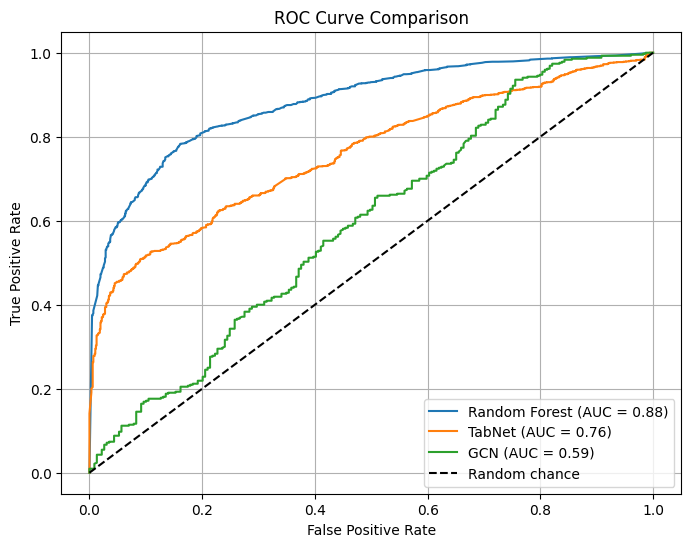

In [51]:
# First, get GCN probabilities
#_, y_prob_gcn = evaluate(val_loader)  # Returns acc, probs
acc_gcn, auc_gcn, y_val_gcn, y_prob_gcn = evaluate(val_loader)

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_curves(model_probs):
    plt.figure(figsize=(8, 6))

    for model_name, (y_true, probs) in model_probs.items():
        fpr, tpr, _ = roc_curve(y_true, probs)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--", label="Random chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

# Call using correct y-values from each source
plot_roc_curves({
    "Random Forest": (y_val_split, rf_probs),
    "TabNet": (y_val_tab, tabnet_probs),
    "GCN": (y_val_gcn, y_prob_gcn),
})


In [64]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc

def plotly_roc_curves(model_probs):
    fig = go.Figure()

    # Add ROC curves
    for model_name, (y_true, probs) in model_probs.items():
        fpr, tpr, _ = roc_curve(y_true, probs)
        roc_auc_val = auc(fpr, tpr)

        fig.add_trace(go.Scatter(
            x=fpr, y=tpr,
            mode='lines',
            name=f"{model_name} (AUC = {roc_auc_val:.2f})",
            hovertemplate='FPR: %{x:.2f}<br>TPR: %{y:.2f}<extra></extra>'
        ))

    # Diagonal random chance line
    fig.add_trace(go.Scatter(
        x=[0, 1], y=[0, 1],
        mode='lines',
        line=dict(dash='dash', color='gray'),
        name='Random chance',
        hoverinfo='skip'
    ))

    fig.update_layout(
        title={
                'text': "ROC Curve Comparison",
                'y':0.98,
                'x':0.5,
                'xanchor': 'center',
                'yanchor': 'top',
                'font': {'size': 14}
            },
        xaxis=dict(
            title_text="False Positive Rate",
            title_font=dict(size=9), # Size for x-axis label
            tickfont=dict(size=8),
            title_standoff=5,    # Size for x-axis tick labels
            showgrid=False        # Remove grid lines for a cleaner look
        ),
        yaxis=dict(
            title_text="True Positive Rate",
            title_font=dict(size=9), # Size for y-axis label
            tickfont=dict(size=8),
            title_standoff=5,    # Size for y-axis tick labels
            showgrid=False        # Remove grid lines for a cleaner look
        ),

        height=500,
        width=600,
        template="plotly_white",
        font=dict(size=12),
        legend=dict(orientation='h', yanchor='bottom', y=-0.25, x=0.5, xanchor='center')
    )

    fig.show()


In [65]:
plotly_roc_curves({
    "Random Forest": (y_val_split, rf_probs),
    "TabNet": (y_val_tab, tabnet_probs),
    "GCN": (y_val_gcn, y_prob_gcn),
})


In [ ]:
############# FUTURE WORK ################

In [28]:
from sklearn.model_selection import train_test_split
import torch
from torch_geometric.data import Data
import pandas as pd
import numpy as np

# ---------------------------
# Step 1: Sort and Label Tasks
# ---------------------------
df_all2 = df_all2.sort_values(by=['proj_id', 'target_start_date'])

# Create per-project sequential task ID
df_all2['local_task_seq_id'] = df_all2.groupby('proj_id').cumcount() + 1

# Optional: for debugging or visualization
df_all2['task_seq_label'] = df_all2['proj_id'].astype(str) + "_T" + df_all2['local_task_seq_id'].astype(str)

# ---------------------------
# Step 2: Train/Val/Test Project Split
# ---------------------------
unique_proj_ids = df_all2['proj_id'].unique()
train_ids, test_ids = train_test_split(unique_proj_ids, test_size=0.2, random_state=42)
train_ids, val_ids = train_test_split(train_ids, test_size=0.25, random_state=42)  # 60/20/20

# ---------------------------
# Step 3: Encode Features
# ---------------------------
# Ensure ordinal date columns exist
for col in date_cols:
    df_all2[col + "_ordinal"] = pd.to_datetime(df_all2[col], errors='coerce').map(
        lambda x: x.toordinal() if pd.notnull(x) else -1
    )

# Final feature column list
feature_cols = numeric_cols + [col + "_ordinal" for col in date_cols] + ['has_suspend', 'has_resume']
df_all2[feature_cols] = df_all2[feature_cols].astype(np.float32)
df_all2['on_time_flag'] = df_all2['on_time_flag'].astype(int)

# ---------------------------
# Step 4: Build PyG Graph
# ---------------------------
from torch_geometric.data import Data

def build_project_graph(df_proj):
    # Sort tasks by sequence
    df_proj = df_proj.sort_values(by='local_task_seq_id')

    # Node features
    x = torch.tensor(df_proj[feature_cols].values, dtype=torch.float)
    x = torch.nan_to_num(x, nan=0.0, posinf=1e5, neginf=-1e5)  # ✅ sanitize here

    # Labels per node
    y = torch.tensor(df_proj['on_time_flag'].values, dtype=torch.long)

    # Build edges between sequential tasks
    edges = []
    for i in range(len(df_proj) - 1):
        src = i
        tgt = i + 1
        edges.append((src, tgt))
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous() if edges else torch.empty((2, 0), dtype=torch.long)

    return Data(x=x, edge_index=edge_index, y=y)

In [29]:
train_graphs = []
val_graphs = []
test_graphs = []

for proj_id, group in df_all2.groupby('proj_id'):
    graph = build_project_graph(group)
    if proj_id in train_ids:
        train_graphs.append(graph)
    elif proj_id in val_ids:
        val_graphs.append(graph)
    elif proj_id in test_ids:
        test_graphs.append(graph)

from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=32)
test_loader = DataLoader(test_graphs, batch_size=32)

from collections import Counter

val_classes = []
for batch in val_loader:
    val_classes.extend(batch.y.tolist())

print("Validation set class distribution:", Counter(val_classes))


Validation set class distribution: Counter({0: 988, 1: 420})
